# Praktikum K-Nearest Neighbors (KNN)
### 4233201 – Kecerdasan Buatan | Semester Ganjil TA 2026/2027
### Week/Sesi: 4/2 | Nama: Tika Altiora Sitanggang | NIM: 42324025

Tujuan praktikum: mahasiswa mampu melakukan klasifikasi menggunakan algoritma KNN.

Isi laporan:

| Bagian | Isi |
|---|---|
| 1 | Klasifikasi KNN pada dataset Iris (dari Scikit-Learn) |
| 2 | Klasifikasi KNN pada dataset athletes.csv (prediksi atlet masuk draft) |
| 3 | Tugas 1: prediksi 2 data atlet |
| 4 | Tugas 2: prediksi 3 data bunga Iris |
| 5 | Kesimpulan |

# BAGIAN 1. Klasifikasi KNN pada Dataset Iris

## 1.1 Import Library dan Load Dataset
Dataset pertama adalah **Iris** yang diambil langsung dari Scikit-Learn. Dataset ini terdiri atas
150 data bunga dengan **4 fitur** (sepal length, sepal width, petal length, petal width) dan
**3 kelas spesies** (setosa, versicolor, virginica), sehingga cocok untuk menguji performa algoritma klasifikasi.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from pandas.plotting import parallel_coordinates

# Load dataset Iris dari scikit-learn
iris = load_iris()

## 1.2 Konversi Data ke DataFrame dan Pemisahan Fitur (X) dengan Label (y)
Data dikonversi menjadi **DataFrame Pandas** agar lebih mudah diolah dan divisualisasikan.
Kolom `Species` berisi nama spesies sebagai label. Variabel `X` menyimpan keempat fitur,
sedangkan `y` menyimpan label (target).

In [9]:
# Konversi data menjadi DataFrame Pandas
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["Species"] = iris.target_names[iris.target]

# Definisikan X (fitur) dan y (target/label)
X_iris = df_iris.drop(columns=["Species"])
y_iris = df_iris["Species"]

print(X_iris)

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


In [10]:
y_iris

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: str

Dataset terdiri atas 150 baris dan 4 kolom fitur. Setiap spesies memiliki 50 data,
sehingga kelasnya seimbang (balanced).

## 1.3 Visualisasi Data dengan Parallel Coordinates Plot
Feature space dataset Iris memiliki **4 dimensi**, sehingga tidak bisa digambar dengan scatter plot biasa.
Oleh karena itu digunakan **Parallel Coordinates Plot** untuk memvisualisasikan data berdimensi tinggi.

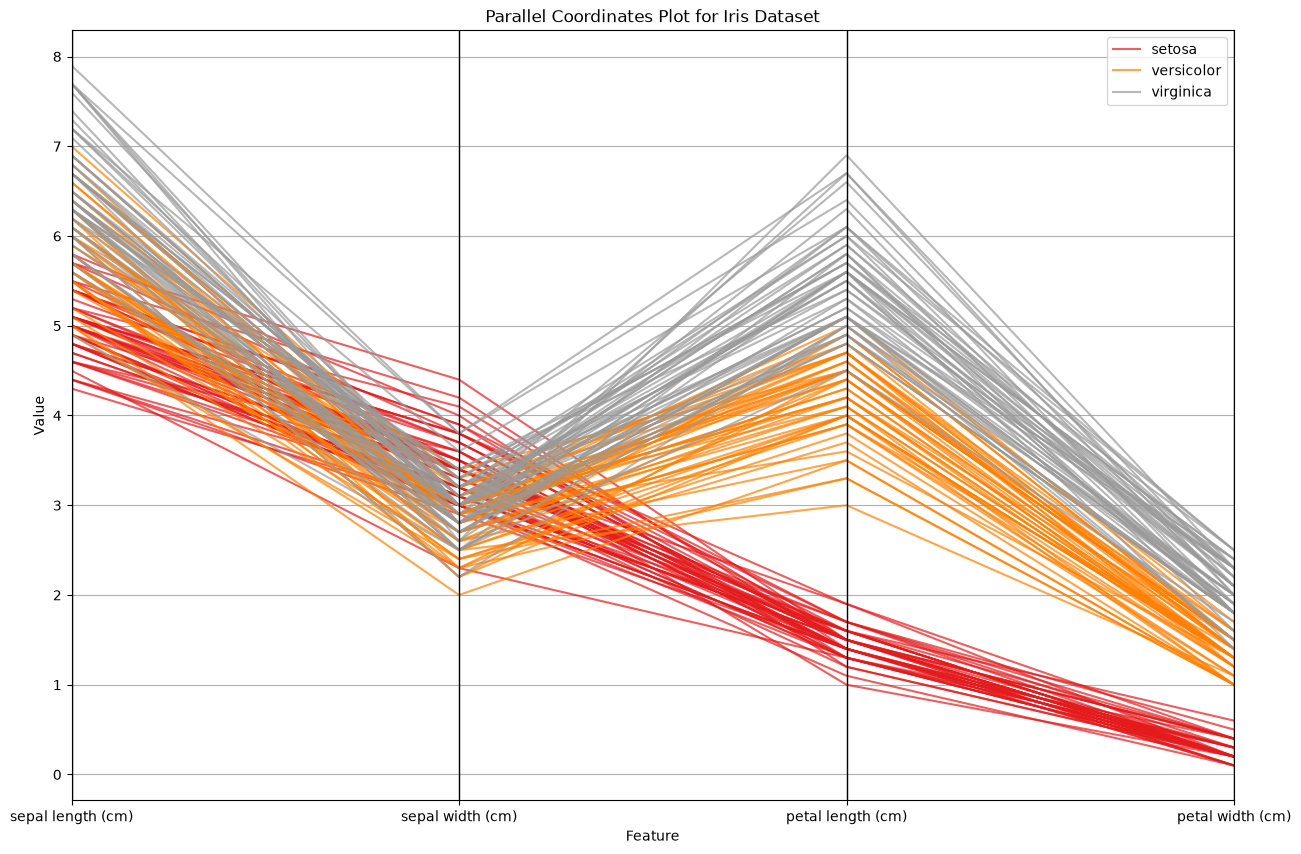

In [11]:
# Plot Parallel Coordinates
plt.figure(figsize=(15, 10))
parallel_coordinates(df_iris, class_column="Species", colormap=plt.cm.Set1, alpha=0.7)
plt.title("Parallel Coordinates Plot for Iris Dataset")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.grid(True)
plt.show()

**Gambar 1.** Parallel Coordinates Plot dataset Iris.

Interpretasi: garis setosa (merah) terpisah sangat jelas dari dua spesies lain, terutama pada
`petal length` dan `petal width` yang nilainya kecil. Garis versicolor dan virginica lebih
berdekatan sehingga lebih mungkin tertukar saat klasifikasi. Fitur petal paling membantu memisahkan kelas.

## 1.4 Encoding Label
Label `Species` berupa teks (string), sehingga diubah menjadi angka (numerik) menggunakan
**LabelEncoder** dari Scikit-Learn. Urutannya mengikuti alfabet: `setosa = 0`, `versicolor = 1`, `virginica = 2`.

In [12]:
from sklearn.preprocessing import LabelEncoder

lab = LabelEncoder()
y_iris = lab.fit_transform(y_iris)
y_iris

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
# Cek pemetaan angka ke nama spesies
print(dict(zip(range(3), lab.classes_)))

{0: 'setosa', 1: 'versicolor', 2: 'virginica'}


## 1.5 Split Data Train dan Test
Data dibagi menjadi 80% data latih (train) dan 20% data uji (test) dengan `random_state=0`
supaya pembagiannya tetap sama setiap kali dijalankan. Hasilnya: 120 data latih dan 30 data uji.

In [14]:
from sklearn.model_selection import train_test_split

X_train_iris, X_test_iris = train_test_split(X_iris, test_size=0.2, random_state=0)
y_train_iris, y_test_iris = train_test_split(y_iris, test_size=0.2, random_state=0)

print("Jumlah data latih:", len(X_train_iris))
print("Jumlah data uji  :", len(X_test_iris))

Jumlah data latih: 120
Jumlah data uji  : 30


## 1.6 Membangun Model KNN (k = 3)
Penjelasan kode berikut:
- `KNeighborsClassifier` diimpor dari Scikit-Learn untuk klasifikasi menggunakan KNN.
- `accuracy_score` diimpor untuk mengukur akurasi model.
- Jarak dihitung dengan `metric='euclidean'`. Alternatif lainnya adalah `metric='minkowski'`.
- `n_neighbors=3` artinya label ditentukan dari 3 tetangga terdekat (voting terbanyak).

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# k = 3
knn_iris = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_iris.fit(X_train_iris, y_train_iris)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 1.7 Prediksi dan Evaluasi Akurasi

In [16]:
y_pred = knn_iris.predict(X_test_iris)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

In [17]:
result = accuracy_score(y_test_iris, y_pred)
result

0.9666666666666667

Akurasi model KNN (k = 3) pada dataset Iris adalah 0,9667 (96,67%). Dari 30 data uji,
29 diprediksi benar dan hanya 1 yang salah. Artinya KNN bekerja sangat baik pada dataset ini.

# BAGIAN 2. Klasifikasi KNN pada Dataset athletes.csv

## 2.1 Load Dataset
Dataset athletes.csv digunakan untuk menentukan apakah seorang atlet masuk draft (yes/no)
berdasarkan dua fitur utama:
- `speed`: kecepatan atlet
- `agility`: kelincahan atlet

Kolom `draft` adalah target (label kelas) yang menunjukkan apakah atlet dipilih dalam draft atau tidak.

In [18]:
df_ath = pd.read_csv('athletes.csv')
print(df_ath)

    id  speed  agility draft
0    1   2.50     6.00    no
1    2   3.75     8.00    no
2    3   2.25     5.50    no
3    4   3.25     8.25    no
4    5   2.75     7.50    no
5    6   4.50     5.00    no
6    7   3.50     5.25    no
7    8   3.00     3.25    no
8    9   4.00     4.00    no
9   10   4.25     3.75    no
10  11   2.00     2.00    no
11  12   5.00     2.50    no
12  13   8.25     8.50    no
13  14   5.75     8.75   yes
14  15   4.75     6.25   yes
15  16   5.50     6.75   yes
16  17   5.25     9.50   yes
17  18   7.00     4.25   yes
18  19   7.50     8.00   yes
19  20   7.25     5.75   yes


Dataset terdiri atas 20 baris data (13 atlet `no` dan 7 atlet `yes`). Kolom `id` hanya sebagai
penomoran sehingga tidak dipakai sebagai fitur.

## 2.2 Pemisahan Fitur dan Target

In [19]:
feature_columns = ['speed', 'agility']
X_ath = df_ath[feature_columns].values
y_ath = df_ath['draft'].values

In [20]:
X_ath

array([[2.5 , 6.  ],
       [3.75, 8.  ],
       [2.25, 5.5 ],
       [3.25, 8.25],
       [2.75, 7.5 ],
       [4.5 , 5.  ],
       [3.5 , 5.25],
       [3.  , 3.25],
       [4.  , 4.  ],
       [4.25, 3.75],
       [2.  , 2.  ],
       [5.  , 2.5 ],
       [8.25, 8.5 ],
       [5.75, 8.75],
       [4.75, 6.25],
       [5.5 , 6.75],
       [5.25, 9.5 ],
       [7.  , 4.25],
       [7.5 , 8.  ],
       [7.25, 5.75]])

In [21]:
y_ath

<ArrowStringArray>
[ 'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',  'no',
  'no',  'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes']
Length: 20, dtype: str

## 2.3 Encoding Label
Label `yes` dan `no` diubah menjadi angka: `no = 0` dan `yes = 1`.

In [22]:
# encode data y menjadi numerik
en = LabelEncoder()
y_ath = en.fit_transform(y_ath)
y_ath

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [23]:
print(dict(zip(range(2), en.classes_)))

{0: 'no', 1: 'yes'}


## 2.4 Visualisasi Data (Scatter Plot)
Karena hanya ada 2 fitur, data bisa digambar langsung pada bidang 2 dimensi.
Titik merah adalah atlet yang tidak masuk draft (`no`) dan titik hijau adalah atlet yang masuk draft (`yes`).

['r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'r' 'g' 'g' 'g' 'g' 'g'
 'g' 'g']


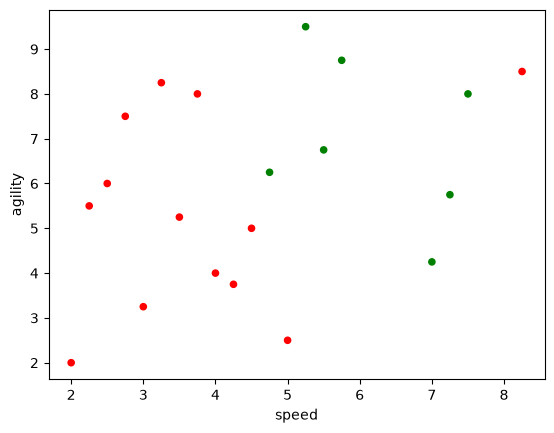

In [39]:
df_ath['key1'] = y_ath
colors = np.where(df_ath["key1"] == 0, 'r', 'g')
print(colors)

df_ath.plot.scatter(x='speed', y='agility', c=colors)
plt.show()

**Gambar 2.** Sebaran data atlet berdasarkan `speed` dan `agility`.

Interpretasi: atlet dengan `speed` tinggi dan `agility` cukup tinggi umumnya masuk draft (hijau).
Namun ada satu titik merah di kanan atas (speed 8,25 dan agility 8,5) yang letaknya dekat dengan titik-titik hijau.
Titik pencilan seperti ini bisa menyulitkan KNN, terutama jika nilai K terlalu kecil.

## 2.5 Split Data Train dan Test
Sama seperti sebelumnya, data dibagi 80% latih dan 20% uji. Karena datanya hanya 20 baris,
data latih berjumlah 16 dan data uji hanya **4**. Ini berpengaruh pada akurasi, karena satu data
salah saja menurunkan akurasi sebesar 25%.

In [25]:
# split train test
X_train, X_test = train_test_split(X_ath, test_size=0.2, random_state=0)
y_train, y_test = train_test_split(y_ath, test_size=0.2, random_state=0)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji  :", len(X_test))

Jumlah data latih: 16
Jumlah data uji  : 4


## 2.6 Model KNN dengan k = 5

In [26]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [27]:
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 1, 0])

In [28]:
result = accuracy_score(y_test, y_pred)
result

0.75

Akurasi dengan **k = 5** adalah **0,75 (75%)**, yaitu 3 dari 4 data uji benar. Belum tentu k = 5 adalah
nilai terbaik, sehingga perlu dicari nilai K yang tepat pada bagian berikutnya.

## 2.7 Mencari Nilai K yang Tepat
Untuk menemukan nilai K yang tepat, dicoba beberapa variasi nilai K (1 sampai 10), lalu dilihat
akurasinya pada data uji.

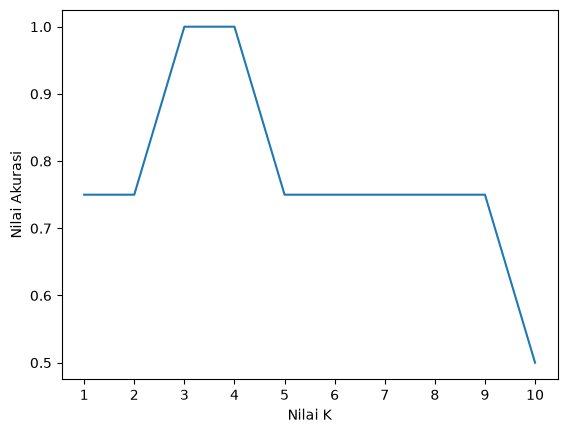

In [29]:
array_k = []
for i in range(1, 11):
    model_k = KNeighborsClassifier(n_neighbors=i, metric='euclidean')
    model_k.fit(X_train, y_train)

    y_pred = model_k.predict(X_test)

    # Calculate accuracy
    result = accuracy_score(y_test, y_pred)

    # Store the accuracy result
    array_k.append(result)

plt.plot(array_k)
plt.ylabel('Nilai Akurasi')
plt.xlabel('Nilai K')
plt.xticks(np.arange(10), ('1','2','3','4','5','6','7','8','9','10'))
plt.show()

In [30]:
# Tabel akurasi tiap nilai K
pd.DataFrame({'K': range(1, 11), 'Akurasi': array_k})

,K,Akurasi
0,1,0.75
1,2,0.75
2,3,1.00
3,4,1.00
4,5,0.75
5,6,0.75
6,7,0.75
7,8,0.75
8,9,0.75
9,10,0.50


**Gambar 3.** Grafik akurasi terhadap nilai K.

Interpretasi:
- Akurasi tertinggi 1,0 (100%) diperoleh pada K = 3 dan K = 4.
- Untuk K = 1, 2 dan 5 sampai 9 akurasinya 0,75, sedangkan K = 10 turun menjadi 0,5.
  Nilai K terlalu besar membuat prediksi didominasi kelas mayoritas (`no`).
- Dipilih K = 3 karena akurasinya tertinggi dan bernilai ganjil, sehingga voting tidak berpotensi seri
  (K = 4 bisa menghasilkan suara 2 lawan 2).

# BAGIAN 3. Tugas 1: Prediksi Atlet Masuk Draft (Yes/No)

Prediksi apakah atlet dengan data berikut masuk draft:
1. `input = [7.5, 7.0]`
2. `input = [4.0, 6.5]`

Model yang dipakai adalah KNN dengan K = 3 (K terbaik dari Bagian 2.7), dilatih dengan data latih yang sama.
Setiap data input berisi urutan `[speed, agility]`.

In [31]:
knn_ath = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_ath.fit(X_train, y_train)

input_atlet = np.array([[7.5, 7.0],
                        [4.0, 6.5]])

pred_atlet = knn_ath.predict(input_atlet)
label_atlet = en.inverse_transform(pred_atlet)

hasil_atlet = pd.DataFrame(input_atlet, columns=['speed', 'agility'])
hasil_atlet['Prediksi (angka)'] = pred_atlet
hasil_atlet['Prediksi draft'] = label_atlet
hasil_atlet

,speed,agility,Prediksi (angka),Prediksi draft
0,7.5,7.0,1,yes
1,4.0,6.5,1,yes


### Bukti: 3 Tetangga Terdekat
Kode berikut menampilkan 3 tetangga terdekat dari tiap input beserta jaraknya (Euclidean),
sehingga proses voting KNN bisa diperiksa langsung.

In [32]:
jarak, idx = knn_ath.kneighbors(input_atlet)

for n, (d, ix) in enumerate(zip(jarak, idx), start=1):
    print(f"Input {n}: {input_atlet[n-1]}")
    tabel = pd.DataFrame({
        'speed'  : X_train[ix][:, 0],
        'agility': X_train[ix][:, 1],
        'draft'  : en.inverse_transform(y_train[ix]),
        'jarak'  : d.round(3)
    })
    print(tabel.to_string(index=False))
    print()

Input 1: [7.5 7. ]
 speed  agility draft  jarak
  8.25     8.50    no  1.677
  5.50     6.75   yes  2.016
  5.75     8.75   yes  2.475

Input 2: [4.  6.5]
 speed  agility draft  jarak
  4.75     6.25   yes  0.791
  3.50     5.25    no  1.346
  5.50     6.75   yes  1.521



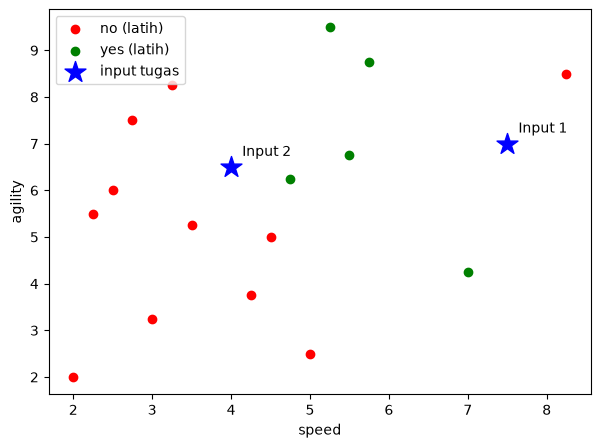

In [33]:
# Visualisasi: titik baru (bintang biru) di antara data latih
plt.figure(figsize=(7, 5))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], c='r', label='no (latih)')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], c='g', label='yes (latih)')
plt.scatter(input_atlet[:, 0], input_atlet[:, 1], c='b', marker='*', s=250, label='input tugas')
for n, p in enumerate(input_atlet, start=1):
    plt.annotate(f'Input {n}', p, textcoords='offset points', xytext=(8, 8))
plt.xlabel('speed')
plt.ylabel('agility')
plt.legend()
plt.show()

**Gambar 4.** Posisi dua data input tugas terhadap data latih.

### Hasil dan Analisis Tugas 1
| No | Input `[speed, agility]` | 3 Tetangga Terdekat (label) | Hasil Voting | Prediksi |
|---|---|---|---|---|
| 1 | `[7.5, 7.0]` | no, yes, yes | 2 yes lawan 1 no | Yes (masuk draft) |
| 2 | `[4.0, 6.5]` | yes, no, yes | 2 yes lawan 1 no | Yes (masuk draft) |

- Input 1 berada di area `speed` tinggi. Tetangga terdekatnya adalah atlet `[8.25, 8.5]` (no) yang menjadi
  titik pencilan, lalu dua atlet `yes`. Suara terbanyak adalah `yes`.
- Input 2 berada di daerah perbatasan antara kelas `no` dan `yes`, dan hasilnya tipis (2 lawan 1).
  Prediksi ini paling sensitif terhadap pilihan model, lihat pengecekan tambahan di bawah.

In [34]:
# Pengecekan tambahan: bandingkan hasil untuk beberapa nilai K dan jika model dilatih dengan seluruh 20 data
baris = []
for k in [1, 3, 4, 5]:
    m1 = KNeighborsClassifier(n_neighbors=k, metric='euclidean').fit(X_train, y_train)
    m2 = KNeighborsClassifier(n_neighbors=k, metric='euclidean').fit(X_ath, y_ath)
    baris.append({
        'K': k,
        'Input 1 (data latih 16)': en.inverse_transform(m1.predict(input_atlet))[0],
        'Input 2 (data latih 16)': en.inverse_transform(m1.predict(input_atlet))[1],
        'Input 1 (seluruh 20 data)': en.inverse_transform(m2.predict(input_atlet))[0],
        'Input 2 (seluruh 20 data)': en.inverse_transform(m2.predict(input_atlet))[1],
    })
pd.DataFrame(baris)

,K,Input 1 (data latih 16),Input 2 (data latih 16),Input 1 (seluruh 20 data),Input 2 (seluruh 20 data)
0,1,no,yes,yes,yes
1,3,yes,yes,yes,no
2,4,yes,no,yes,no
3,5,yes,no,yes,no


Catatan dari tabel pengecekan:
- Input 1 bernilai `yes` untuk K = 3, 4, 5 (baik dengan 16 maupun 20 data latih). Hanya K = 1 dengan 16 data latih yang
  menghasilkan `no`, karena tetangga terdekatnya adalah titik pencilan `[8.25, 8.5]`. Jadi hasilnya cukup stabil.
- Input 2 adalah kasus perbatasan. Dengan 16 data latih hasilnya `yes` pada K = 1 dan 3, tetapi berubah menjadi `no`
  pada K = 4 dan 5. Jika model dilatih dengan seluruh 20 data, hasilnya `no` mulai K = 3.
- Jawaban resmi tugas ini mengikuti alur praktikum, yaitu K = 3 dengan data latih hasil split, sehingga
  Input 1 = yes dan Input 2 = yes.

# BAGIAN 4. Tugas 2: Prediksi Species Bunga Iris

Untuk dataset Iris, prediksi species dari data berikut. Urutan fitur:
`[sepal length, sepal width, petal length, petal width]`.
1. `input_data = [[7.1, 1.2, 5.0, 2.0]]`
2. `input_data = [[5.1, 3.5, 1.4, 0.2]]`
3. `input_data = [[6.4, 3.7, 4.2, 2.2]]`

Model yang dipakai adalah `knn_iris` (K = 3) dari Bagian 1. Input dibuat sebagai DataFrame dengan nama kolom yang sama
dengan data latih supaya tidak muncul peringatan nama fitur.

In [35]:
input_iris = pd.DataFrame([[7.1, 1.2, 5.0, 2.0],
                           [5.1, 3.5, 1.4, 0.2],
                           [6.4, 3.7, 4.2, 2.2]],
                          columns=iris.feature_names)

pred_iris = knn_iris.predict(input_iris)
label_iris = lab.inverse_transform(pred_iris)

hasil_iris = input_iris.copy()
hasil_iris['Prediksi (angka)'] = pred_iris
hasil_iris['Prediksi species'] = label_iris
hasil_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Prediksi (angka),Prediksi species
0,7.1,1.2,5.0,2.0,2,virginica
1,5.1,3.5,1.4,0.2,0,setosa
2,6.4,3.7,4.2,2.2,1,versicolor


### Bukti: 3 Tetangga Terdekat

In [36]:
jarak, idx = knn_iris.kneighbors(input_iris)

for n, (d, ix) in enumerate(zip(jarak, idx), start=1):
    print(f"Input {n}: {input_iris.iloc[n-1].values}")
    tabel = X_train_iris.iloc[ix].copy()
    tabel['species'] = lab.inverse_transform(y_train_iris[ix])
    tabel['jarak'] = d.round(3)
    print(tabel.to_string(index=False))
    print()

Input 1: [7.1 1.2 5.  2. ]
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)    species  jarak
               6.2               2.2                4.5               1.5 versicolor  1.520
               6.3               2.5                5.0               1.9  virginica  1.530
               6.0               2.2                5.0               1.5  virginica  1.568

Input 2: [5.1 3.5 1.4 0.2]
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species  jarak
               5.1               3.5                1.4               0.2  setosa  0.000
               5.1               3.5                1.4               0.3  setosa  0.100
               5.0               3.6                1.4               0.2  setosa  0.141

Input 3: [6.4 3.7 4.2 2.2]
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)    species  jarak
               6.0               3.4                4.5               1.6 versicolor  0.837
         

### Hasil dan Analisis Tugas 2
| No | Input | 3 Tetangga Terdekat | **Prediksi** |
|---|---|---|---|
| 1 | `[7.1, 1.2, 5.0, 2.0]` | versicolor, virginica, virginica | **virginica** |
| 2 | `[5.1, 3.5, 1.4, 0.2]` | setosa, setosa, setosa | **setosa** |
| 3 | `[6.4, 3.7, 4.2, 2.2]` | versicolor, versicolor, versicolor | **versicolor** |

- Input 2 sangat yakin `setosa`: datanya identik dengan salah satu data latih (jarak 0) dan tetangga lainnya sangat dekat.
- Input 1 diprediksi `virginica` dengan suara 2 lawan 1. Nilai `sepal width` 1,2 cm jauh di bawah data latih (jarak
  tetangga terdekat sekitar 1,5), sehingga prediksinya kurang yakin dibanding input 2.
- Input 3 diprediksi `versicolor` dengan 3 suara bulat. Nilai `sepal width` 3,7 dan `petal width` 2,2 tergolong tidak biasa
  untuk versicolor, tetapi ukuran petal length 4,2 paling dekat dengan kelompok versicolor.

# BAGIAN 5. Kesimpulan

1. Algoritma KNN mengklasifikasikan data baru berdasarkan voting K tetangga terdekat yang jaraknya dihitung
   dengan Euclidean distance.
2. Pada dataset Iris (K = 3), akurasi yang diperoleh adalah 0,9667 (96,67%).
3. Pada dataset athletes.csv, K = 5 hanya menghasilkan akurasi 0,75. Setelah mencoba K = 1 sampai 10, akurasi terbaik
   1,0 diperoleh pada K = 3 dan K = 4, sehingga dipilih K = 3.
4. Hasil Tugas 1: `[7.5, 7.0]` diprediksi Yes (masuk draft) dan `[4.0, 6.5]` diprediksi Yes (masuk draft)
   (kasus kedua berada di perbatasan kelas sehingga hasilnya tipis, 2 suara lawan 1).
5. Hasil Tugas 2: `[7.1, 1.2, 5.0, 2.0]` diprediksi virginica, `[5.1, 3.5, 1.4, 0.2]` diprediksi setosa,
   dan `[6.4, 3.7, 4.2, 2.2]` diprediksi versicolor.
6. Data uji pada dataset athletes hanya 4 baris, jadi akurasi 100% pada K = 3 belum tentu stabil. Pada data yang
   lebih besar, pemilihan K sebaiknya memakai cross validation.